# 🎯 Signal Detection Theory

Simulating detection of a known signal (chirp) in noise using matched filtering and ROC curves.

## 🔹 1. Generate a Known Signal (LFM Chirp)

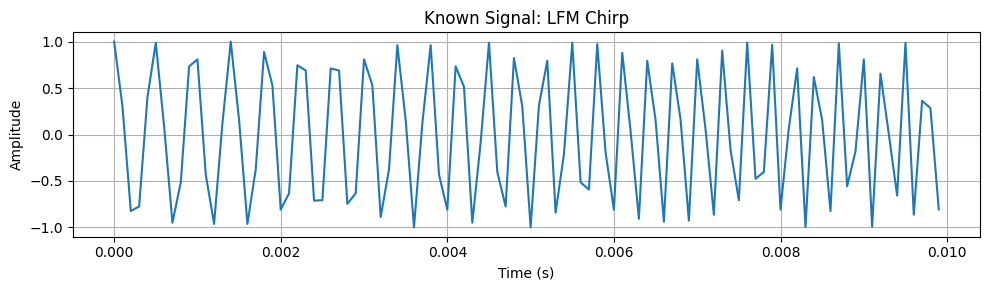

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 10000
duration = 0.01
f0, f1 = 2000, 4000
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
k = (f1 - f0) / duration
template = np.cos(2 * np.pi * (f0 * t + 0.5 * k * t**2))

plt.figure(figsize=(10, 3))
plt.plot(t, template)
plt.title("Known Signal: LFM Chirp")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 2. Simulate Received Signal with Noise (H0 and H1)

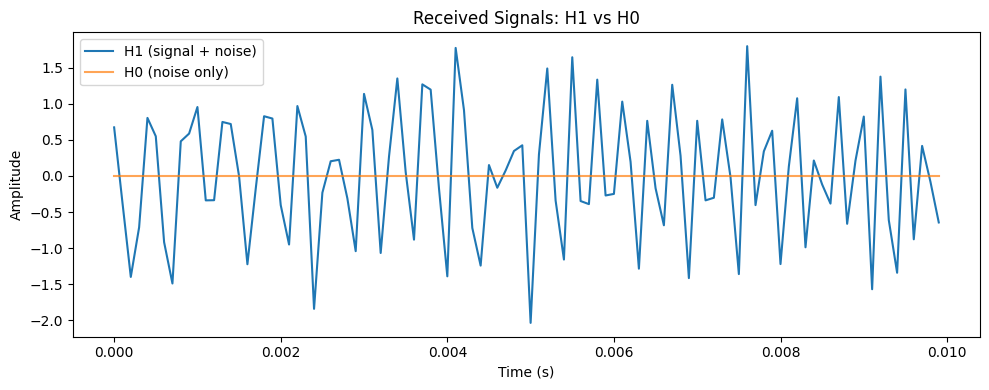

In [2]:
def add_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    noise_power = signal_power / (10**(snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), size=signal.shape)
    return signal + noise

# H1: signal + noise
rx_H1 = add_noise(template, snr_db=3)

# H0: noise only
rx_H0 = add_noise(np.zeros_like(template), snr_db=3)

plt.figure(figsize=(10, 4))
plt.plot(t, rx_H1, label="H1 (signal + noise)")
plt.plot(t, rx_H0, label="H0 (noise only)", alpha=0.7)
plt.title("Received Signals: H1 vs H0")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

## 🔹 3. Matched Filtering

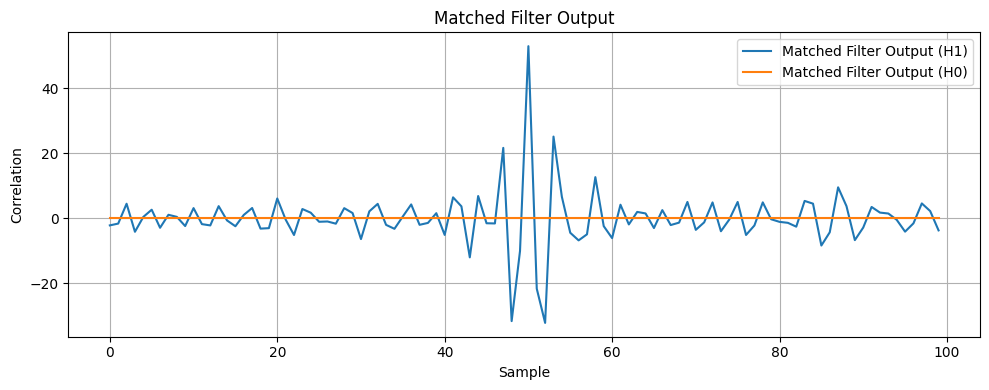

In [3]:
from scipy.signal import correlate

def matched_filter(received, template):
    return correlate(received, template, mode='same')

# Apply matched filter
mf_output_H1 = matched_filter(rx_H1, template)
mf_output_H0 = matched_filter(rx_H0, template)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(mf_output_H1, label="Matched Filter Output (H1)")
plt.plot(mf_output_H0, label="Matched Filter Output (H0)")
plt.title("Matched Filter Output")
plt.xlabel("Sample")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 4. ROC Curve (Probability of Detection vs False Alarm)

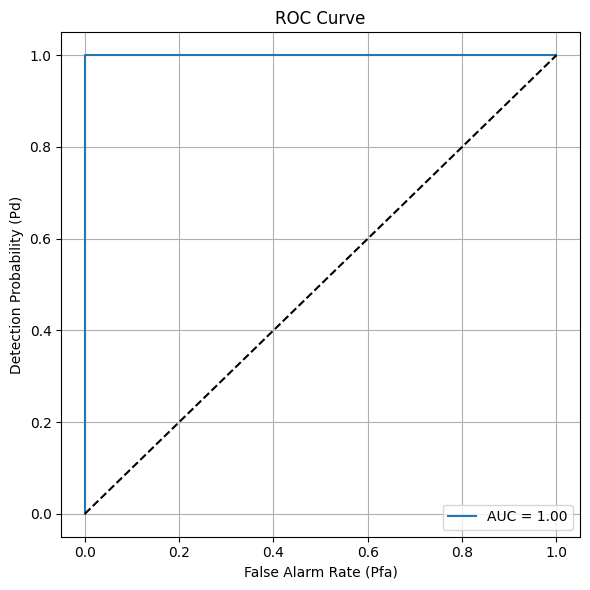

In [4]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Generate multiple test cases
def generate_test_cases(template, snr_db, num_trials=1000):
    scores_H1 = []
    scores_H0 = []
    for _ in range(num_trials):
        rx1 = add_noise(template, snr_db)
        rx0 = add_noise(np.zeros_like(template), snr_db)
        scores_H1.append(np.max(matched_filter(rx1, template)))
        scores_H0.append(np.max(matched_filter(rx0, template)))
    return np.array(scores_H1), np.array(scores_H0)

H1_scores, H0_scores = generate_test_cases(template, snr_db=3)

# Build labels and scores
y_true = np.concatenate([np.ones_like(H1_scores), np.zeros_like(H0_scores)])
y_scores = np.concatenate([H1_scores, H0_scores])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Alarm Rate (Pfa)")
plt.ylabel("Detection Probability (Pd)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## ✅ Summary
- We detect a known signal in noise using matched filtering
- ROC curves let us evaluate performance across thresholds
- Key idea: maximize signal detection while minimizing false alarms